# Logistic Regression

Logistic regression is a statistical method used for binary classification problems.  
It models the probability that a given input belongs to a particular class using a logistic (sigmoid) function.

**Sigmoid Function**:  
The logistic function maps any real-valued number into the range (0, 1), making it suitable for modeling probabilities.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

In logistic regression, the model predicts the probability that the output label is 1 (positive class), given the input features.

The loss function used is **binary cross-entropy**, and the model parameters are typically learned using **gradient descent**.


# Import the relevant libraries

In [269]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# Single

## (1) Load, preprocess, and plot

In [270]:
raw_data = pd.read_csv("data/2.01. Admittance.csv")
raw_data

,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No
...,...,...
163,1722,Yes
164,1750,Yes
165,1555,No
166,1524,No


preprocess the data. `sklearn` does not like string target

In [271]:
# Replace all No entries with 0, and all Yes entries with 1
data = raw_data.copy()
data["Admitted"] = data["Admitted"].map({"Yes": 1, "No": 0})
data

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0
...,...,...
163,1722,1
164,1750,1
165,1555,0
166,1524,0


- Let's examine the independent and dependent variables.
- Logistic regression is fundamentally a model designed for binary dependent variables.

In [272]:
# Create the dependent and independent variables
y = data["Admitted"]
X = data["SAT"]

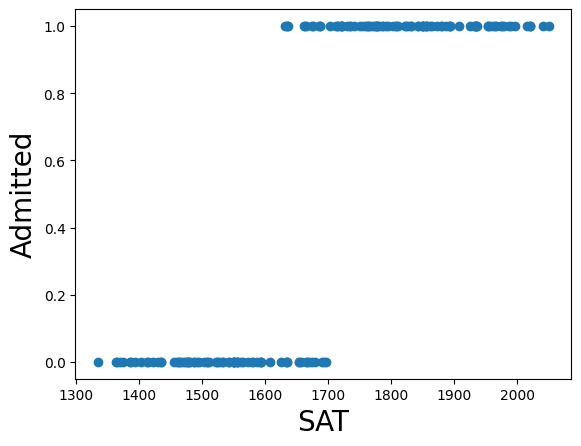

In [273]:
# Create a scatter plot of x1 (SAT, no constant) and y (Admitted)
plt.scatter(X, y)
plt.xlabel("SAT", fontsize=20)
plt.ylabel("Admitted", fontsize=20)
plt.show()

## (2) Try Linear Regression 

Let's try using linear regression on data with a binary target variable and see what happens.

In [274]:
linear_model = LinearRegression() 
linear_model.fit(X.values.reshape(-1, 1), y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [275]:
print(linear_model.coef_)
print(linear_model.intercept_)

[0.00224824]
-3.251858542650684


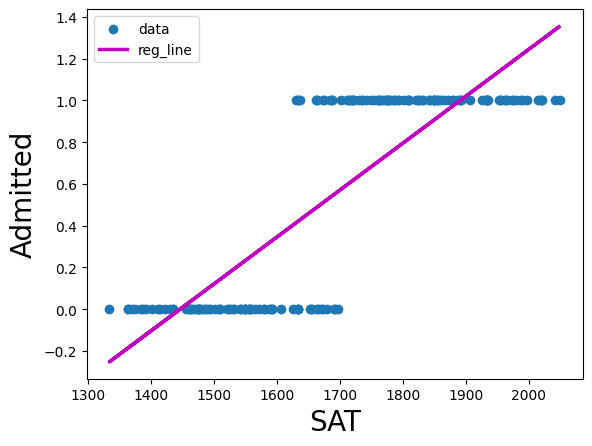

In [276]:
# Create a scatter plot
plt.scatter(X, y)

# Plot the regression line. The coefficients are coming from results_lin.params
y_hat = linear_model.coef_ * X + linear_model.intercept_
plt.plot(X, y_hat, lw=2.5, c='m')

# label resul6
plt.xlabel("SAT", fontsize=20)
plt.ylabel("Admitted", fontsize=20)
plt.legend(["data", "reg_line"])
plt.show()

<Axes: xlabel='SAT', ylabel='Admitted'>

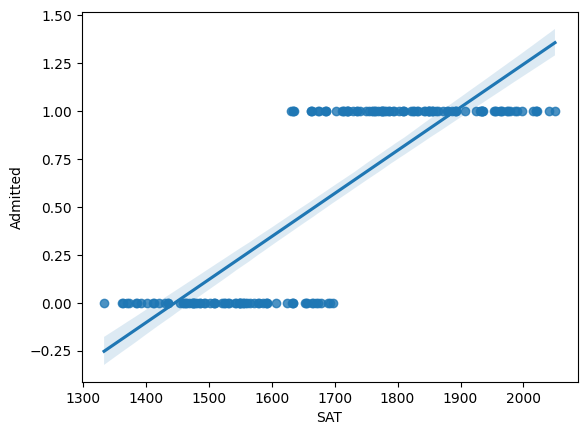

In [277]:
import seaborn as sns
sns.regplot(x=X, y=y)

## (3) Try Logistic Regression
- go to `part (4)` if you want to study about paramter C

In [278]:
model1 = LogisticRegression(solver="liblinear", C=100)
model1.fit(X.values.reshape(-1, 1), y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [279]:
print(f"Intercept: {model1.intercept_}")
print(f"coef: {model1.coef_}")

intercept = model1.intercept_[0]
coef = model1.coef_[0][0]

Intercept: [-30.55733617]
coef: [[0.01842716]]


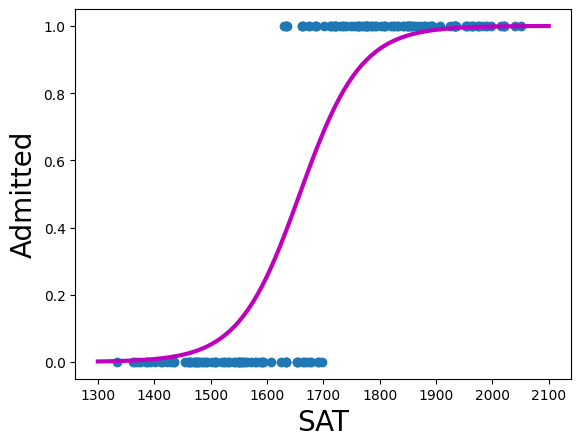

In [280]:
xx = np.linspace(1300, 2100, 100)
mu = 1.0 / (1 + np.exp(-coef * xx - intercept))

plt.scatter(X, y)
plt.xlabel("SAT", fontsize=20)
plt.ylabel("Admitted", fontsize=20)
plt.plot(xx, mu, lw=3, c="m")
plt.show()

### 🔍 Logistic Regression and Odds

Logistic Regression is a classification model that is based on **odds** and more precisely, on **log-odds**.

1. **Probability**  
   For example, if the probability of an event occurring is 0.8 (or 80%), then:

2. **Odds**  
   Odds represent the ratio of the probability that the event occurs to the probability that it does not occur:

   $$
   \text{odds} = \frac{p}{1 - p}
   $$

   Example: 

   $$
   \frac{0.8}{0.2} = 4
   $$

   meaning the event is 4 times more likely to happen than not.

3. **Logit Function (Log-Odds)**  
   Logistic Regression models the **log of the odds** as a linear combination of input features:

   $$
   \log\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n
   $$

4. **Converting Log-Odds to Probability**  
   The model output (log-odds) is converted back to probability using the **sigmoid function**:

   $$
   p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}
   $$

In summary, logistic regression predicts the log-odds of an event, which is then transformed into a probability between 0 and 1 using the sigmoid function.


## (4) Controlling parameter `C` 

🔍 Preventing Overfitting Using `Regularization`

The parameter `C` in `LogisticRegression` controls the strength of `regularization`.

`Regularization` helps control the complexity of a model by penalizing large weights (coefficients) during training.

#### L1 `Regularization` (Lasso)
Tends to keep only the most important features by forcing some coefficients to become exactly zero (useful for feature selection).

#### L2 `Regularization` (Ridge)
The default. It discourages large weights by shrinking less important ones closer to zero, but not exactly zero.

#### Summary:

* The penalty parameter in LogisticRegression is set to `L2` by default but can be changed to `L1`.
* Regularization helps reduce multicollinearity (when features are highly correlated).
* Regularization helps prevent overfitting by simplifying the model.
* The `C` parameter controls the amount of regularization:
* A smaller value of `C` means stronger regularization.
* Stronger regularization simplifies the model and helps prevent overfitting.


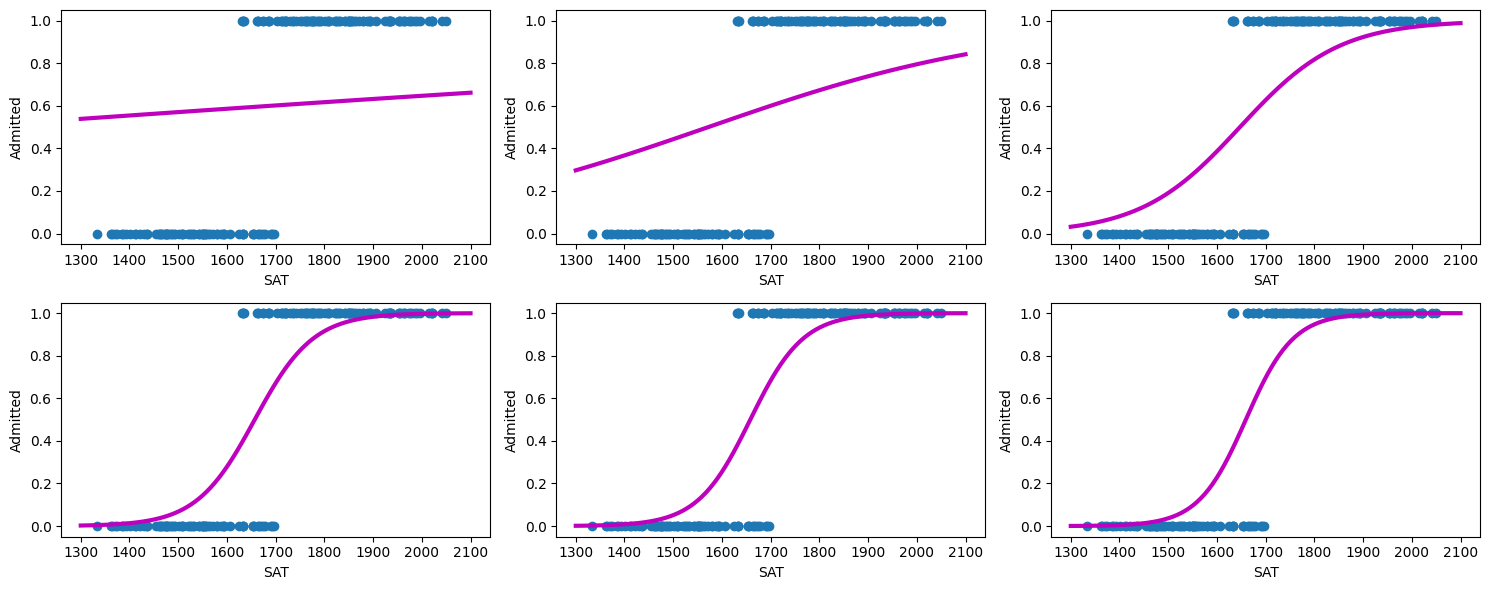

In [281]:
c_list = [0.1, 1, 10, 50, 100, 1000]
plt.figure(figsize=(15, 6))

for i in range(len(c_list)):
    temp_model = LogisticRegression(solver="liblinear", C=c_list[i])
    temp_model.fit(X.values.reshape(-1, 1), y)

    

    xx = np.linspace(1300, 2100, 100)
    mu = 1.0 / (1 + np.exp(-temp_model.coef_[0][0] * xx - temp_model.intercept_[0]))

    plt.subplot(2, 3, i+1)
    plt.scatter(X, y)
    plt.xlabel("SAT")
    plt.ylabel("Admitted")
    plt.plot(xx, mu, lw=3, c="m")

plt.tight_layout()
plt.show()

### Why is underfitting easy to spot, but overfitting is not?

In logistic regression, underfitting is often **visually obvious**, but overfitting is **not easily seen** in the shape of the curve. Here's why:

🔹 1. Logistic Regression is a Linear Model

- Logistic regression models a linear decision boundary using the sigmoid (logistic) function.
- No matter how large the `C` value is, the model cannot "over-curve" like non-linear models.
- The sigmoid curve becomes steeper with a high `C`, but it never turns into a sharp corner or a step function.

🔹 2. Visual Complexity is Limited in 1D

- When visualizing logistic regression with a single feature (e.g., SAT score), the model only fits a 2D sigmoid curve.
- Unlike more complex models (e.g., decision trees or neural networks), logistic regression doesn't show dramatic visual changes—even when overfitting occurs.

🔹 3. Overfitting is Measured by Performance, Not by Shape

- **Underfitting**: Flat sigmoid curve, poor training and validation accuracy.
- **Good fit**: Reasonable curve, high accuracy on both training and validation sets.
- **Overfitting**: Curve might look "fine", but performance on validation data drops significantly compared to training data.


## (5) Predict and Evaluation

In [282]:
model1.predict([[1350], [1520], [1800], [2100], [2350]])

array([0, 0, 1, 1, 1])

### Evaluating Performance of the Model

> A `confusion matrix` is a table that shows whether the predicted categories from the model match the actual categories in the data.

In [283]:
from sklearn.metrics import confusion_matrix

pred = model1.predict(X.values.reshape(-1, 1))

confusion = confusion_matrix(y, pred)

print("Confusion Matrix: \n{}".format(confusion))

Confusion Matrix: 
[[66  8]
 [ 4 90]]


### Evaluating Accuracy of a model

- LinearRegression().score() → R²
- LogisticRegression().score() → Accuracy

In [284]:
model1.score(X.values.reshape(-1, 1), y)

0.9285714285714286

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)


# Multi-Class - Iris Example
We load the Iris dataset from scikit-learn.  
The third column represents petal length, and the fourth column represents petal width.  
The class labels have already been converted to integers:  
0 = Iris-Setosa, 1 = Iris-Versicolor, 2 = Iris-Virginica.


## (1) Preprocess

In [243]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, 2:] # only selectig petal length and width
y = iris.target

print("Features:", iris.feature_names[2:])
print("Class Labels:", np.unique(y))

Features: ['petal length (cm)', 'petal width (cm)']
Class Labels: [0 1 2]


Split the dataset into training and test sets using `train_test_split` from scikit-learn.  
- `test_size=0.3` means 30% of the data is reserved for testing.  
- `random_state=1` ensures reproducibility.  
- `stratify=y` keeps the class distribution balanced in both training and test sets.

In [244]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

print("Label counts in y:", np.bincount(y))
print("Label counts in y_train:", np.bincount(y_train))
print("Label counts in y_test:", np.bincount(y_test))

Label counts in y: [50 50 50]
Label counts in y_train: [35 35 35]
Label counts in y_test: [15 15 15]


We standardize the features so that they have a mean of 0 and a standard deviation of 1.  
This helps many machine learning models perform better, especially those based on distance or gradients.

In [245]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

X_combined_scaled = np.vstack((X_train_scaled, X_test_scaled))
y_combined = np.hstack((y_train, y_test))

## (2) Model Logistic Regression

In [246]:
model2 = LogisticRegression(
    solver="lbfgs", multi_class="auto", C=100.0, random_state=1)
model2.fit(X_train_scaled, y_train)

/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,100.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'auto'


## (3) Interpret: Plotting Decision Regions

This function visualizes the decision boundaries of a classifier in 2D space.  
It works only for datasets with two features.

- Each region is colored based on the predicted class.
- It also plots the actual data points using different markers for each class.

In [247]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # Set up marker shapes and color map
    markers = ("s", "x", "o", "^", "v")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Create a mesh grid over the feature space
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    # Predict the class label for each point on the grid
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    # Draw the decision boundary
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot the class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=cl,
        )

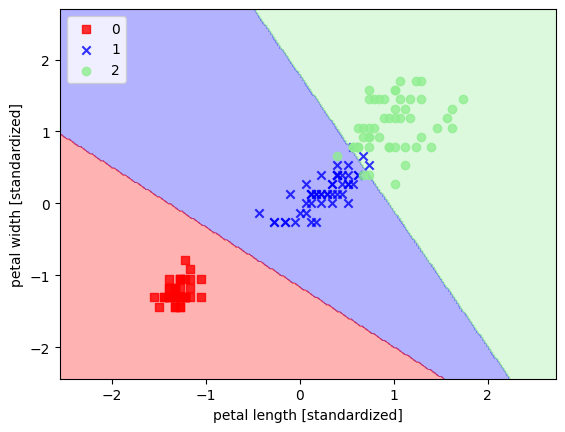

In [248]:
plot_decision_regions(
    X_combined_scaled, y_combined, classifier=model2, test_idx=range(105, 150)
)

# below is optional
plt.xlabel("petal length [standardized]")
plt.ylabel("petal width [standardized]")
plt.legend(loc="upper left")
plt.show()

## (4) Predicting and Evaluation

### `.predict`

In [288]:
model2.predict(X_test_scaled[:5, :])

array([2, 0, 0, 1, 1])

---
### Confusion Matrix (3x3)

In [295]:
from sklearn.metrics import confusion_matrix

pred = model2.predict(X_test_scaled)

confusion = confusion_matrix(y_test, pred)

print("Confusion Matrix: \n{}".format(confusion))

Confusion Matrix: 
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


#### How we interpret above table?
|                            | Predicted: Setosa (0) | Predicted: Versicolor (1) | Predicted: Virginica (2) |
| -------------------------- | --------------------- | ------------------------- | ------------------------ |
| **Actual: Setosa (0)**     | **15** (✔)            | 0                         | 0                        |
| **Actual: Versicolor (1)** | 0                     | **15** (✔)                | 0                        |
| **Actual: Virginica (2)**  | 0                     | 1                         | **14**                   |



- Class 0 (Setosa): All 15 samples were correctly classified → 100%
- Class 1 (Versicolor): All 15 samples were correctly classified → 100%
- Class 2 (Virginica): 14 correctly classified, 1 misclassified as Versicolor → 93.3%

**Overall Accuracy**:  
- (15 + 15 + 14) / 45 = **44 / 45 ≈ 97.8%**

📌 This is an excellent result.  
The model performs very well across all three classes, with only one minor misclassification.


---
### `.score`

In [296]:
model2.score(X_test_scaled, y_test)

0.9777777777777777

---
### `.predict_proba()`


Predicting Class Probabilities

We can also check the **predicted class probabilities** for each class using `.predict_proba()`  
This shows how confident the model is about each prediction.

The results are rounded to 2 decimal places for readability.

In [250]:
prob = model2.predict_proba(X_test_scaled[:5, :])
prob.round(2)

array([[0.  , 0.  , 1.  ],
       [0.99, 0.01, 0.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 0.9 , 0.1 ],
       [0.  , 0.99, 0.01]])

#### How we interpret above table?

| Sample | Setosa (0) | Versicolor (1) | Virginica (2) | **Predicted Class** | **Confidence** |
| ------ | ---------- | -------------- | ------------- | ------------------- | -------------- |
| 1      | 0.00       | 0.00           | **1.00**      | **2 (Virginica)**   | Very high      |
| 2      | **0.99**   | 0.01           | 0.00          | **0 (Setosa)**      | Very high      |
| 3      | **1.00**   | 0.00           | 0.00          | **0 (Setosa)**      | Very high      |
| 4      | 0.00       | **0.90**       | 0.10          | **1 (Versicolor)**  | High           |
| 5      | 0.00       | **0.99**       | 0.01          | **1 (Versicolor)**  | Very high      |




📌 Tip for students:

The highest probability in each row corresponds to the predicted class.

Logistic regression outputs probabilities using the softmax function in the multi-class case.
